In [ ]:
#Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report

In [ ]:
data=pd.read_csv('/content/Heart_Disease_Prediction.csv')

In [ ]:
data.head()

,Age,Sex,Chest pain type,BP,Cholesterol,FBS over 120,EKG results,Max HR,Exercise angina,ST depression,Slope of ST,Number of vessels fluro,Thallium,Heart Disease
0,70,1,4,130,322,0,2,109,0,2.4,2,3,3,Presence
1,67,0,3,115,564,0,2,160,0,1.6,2,0,7,Absence
2,57,1,2,124,261,0,0,141,0,0.3,1,0,7,Presence
3,64,1,4,128,263,0,0,105,1,0.2,2,1,7,Absence
4,74,0,2,120,269,0,2,121,1,0.2,1,1,3,Absence


In [ ]:
data.shape

(270, 14)

In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 270 entries, 0 to 269
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Age                      270 non-null    int64  
 1   Sex                      270 non-null    int64  
 2   Chest pain type          270 non-null    int64  
 3   BP                       270 non-null    int64  
 4   Cholesterol              270 non-null    int64  
 5   FBS over 120             270 non-null    int64  
 6   EKG results              270 non-null    int64  
 7   Max HR                   270 non-null    int64  
 8   Exercise angina          270 non-null    int64  
 9   ST depression            270 non-null    float64
 10  Slope of ST              270 non-null    int64  
 11  Number of vessels fluro  270 non-null    int64  
 12  Thallium                 270 non-null    int64  
 13  Heart Disease            270 non-null    object 
dtypes: float64(1), int64(12), 

Data Processing

In [ ]:
X=data.drop("Heart Disease",axis=1)
y=data["Heart Disease"]




#One hot encoding
cat_cols = ['Chest pain type','EKG results','Slope of ST','Number of vessels fluro','Thallium']
encoder=OneHotEncoder(drop="first", sparse_output=False)

X_encoded=pd.DataFrame(encoder.fit_transform(X[cat_cols]),columns=encoder.get_feature_names_out(cat_cols))

#Drop original categorical columns and add encoded
X=X.drop(cat_cols,axis=1)
X=pd.concat([X.reset_index(drop=True),X_encoded.reset_index(drop=True)],axis=1)


scaler=StandardScaler()
X=scaler.fit_transform(X)

In [ ]:
#Splitting the data
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)


Train Logistic Regression model

In [ ]:
model=LogisticRegression()
model.fit(X_train,y_train)

LogisticRegression()

In [ ]:
#predict
y_pred=model.predict(X_test)

Evaluate Model

In [ ]:
accuracy=accuracy_score(y_test,y_pred)

print("Accuracy Score: ",accuracy)


Accuracy Score:  0.9074074074074074


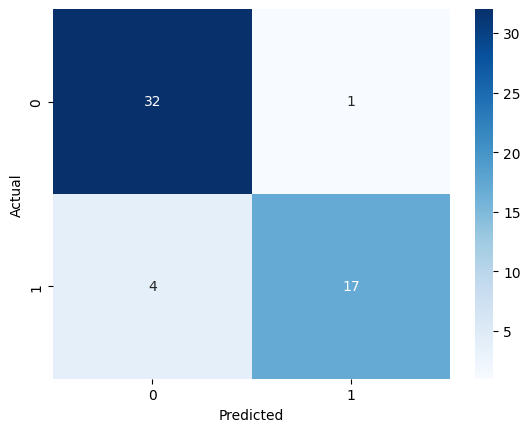

In [ ]:
#Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [ ]:
# Classification report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

     Absence       0.89      0.97      0.93        33
    Presence       0.94      0.81      0.87        21

    accuracy                           0.91        54
   macro avg       0.92      0.89      0.90        54
weighted avg       0.91      0.91      0.91        54



In [ ]:
!pip install joblib


In [ ]:
import joblib
joblib.dump(model,'heart_disease.pkl')

#save scaler and encoder
joblib.dump(scaler,'scaler.pkl')
joblib.dump(encoder,'encoder.pkl')

#DOwnloading files to the system (Colab)
from google.colab import files
files.download('heart_disease.pkl')
files.download('scaler.pkl')
files.download('encoder.pkl')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>